# Sentiment Analysis — Tweet Classification (Positive / Negative / Neutral)

**Objective:** Build a machine learning model that classifies the sentiment of text data, to provide insight into public opinion / customer feedback.

**Dataset:** `tweet_sentiment_dataset.xlsx` — 3,534 labelled tweets, each tagged `positive`, `negative`, or `neutral`, plus metadata (time of tweet, user age bracket, country) that isn't used for the text model itself but is available for further slicing if desired.

**Tech stack:** Python · pandas · scikit-learn · NLTK · WordCloud · matplotlib · seaborn

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'tweet_sentiment_dataset.xlsx'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'tweet_sentiment_dataset.xlsx' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'tweet_sentiment_dataset.xlsx' in the working directory.


In [1]:
# Install/verify required packages (Colab has most pre-installed; wordcloud usually needs installing)
%pip install -q wordcloud nltk openpyxl

## 1. Setup & Imports

In [2]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

pd.set_option('display.max_colwidth', 120)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

## 2. Load Dataset & Inspect Class Distribution

In [ ]:
df_raw = pd.read_excel(DATA_PATH)
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (3534, 9)


,textID,text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,f87dea47db,Last session of the day http://twitpic.com/67ezh,neutral,morning,0-20,Afghanistan,38928346,652860,60
1,96d74cb729,Shanghai is also really exciting (precisely -- skyscrapers galore). Good tweeps in China: (SH) (BJ).,positive,noon,21-30,Albania,2877797,27400,105
2,eee518ae67,"Recession hit Veronique Branquinho, she has to quit her company, such a shame!",negative,night,31-45,Algeria,43851044,2381740,18
3,01082688c6,happy bday!,positive,morning,46-60,Andorra,77265,470,164
4,33987a8ee5,http://twitpic.com/4w75p - I like it!!,positive,noon,60-70,Angola,32866272,1246700,26


In [ ]:
# Keep only the columns needed for the text model; drop any rows missing text/label
df = df_raw[['textID', 'text', 'sentiment']].dropna(subset=['text', 'sentiment']).reset_index(drop=True)
print("Shape after dropping empty rows:", df.shape)
print("\nClass distribution:")
print(df['sentiment'].value_counts())
print("\nClass distribution (%):")
print((df['sentiment'].value_counts(normalize=True) * 100).round(1))

Shape after dropping empty rows: (3534, 3)

Class distribution:
sentiment
neutral     1430
positive    1103
negative    1001
Name: count, dtype: int64

Class distribution (%):
sentiment
neutral     40.5
positive    31.2
negative    28.3
Name: proportion, dtype: float64


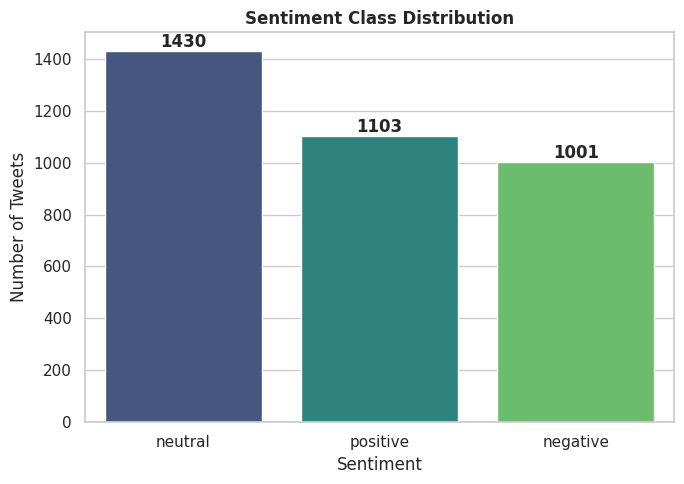

In [ ]:
plt.figure(figsize=(7,5))
order = df['sentiment'].value_counts().index
ax = sns.countplot(data=df, x='sentiment', order=order, hue='sentiment',
                    palette='viridis', legend=False)
plt.title('Sentiment Class Distribution', fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** After removing rows with no text or label, the dataset has **3,534 tweets** split across three classes: **neutral (1,430 / 40%), positive (1,103 / 31%), negative (1,001 / 29%)**. The classes are reasonably balanced — no single class dominates or is a tiny minority — which means accuracy alone will be a fair headline metric, though we still report precision/recall/F1 per class since a mild imbalance can still hide class-specific weaknesses.

## 3. Text Preprocessing Pipeline

Raw tweet text is noisy — URLs, punctuation, mixed casing, stray characters — none of which carry sentiment signal on their own and would otherwise inflate the vocabulary with near-duplicate tokens (`"Good"` vs `"good"` vs `"good!"`). The pipeline below normalises every tweet through the same steps: lowercase → remove URLs/mentions → remove punctuation & digits → tokenise → remove stopwords → lemmatise.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                   # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # remove URLs
    text = re.sub(r'@\w+', ' ', text)                       # remove @mentions
    text = text.replace('`', "'")                          # normalise typographic apostrophes
    text = re.sub(r'[^a-z\s]', ' ', text)                    # 2. remove punctuation & digits
    tokens = word_tokenize(text)                           # 3. tokenisation
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]  # 4. stopword removal
    tokens = [lemmatizer.lemmatize(t) for t in tokens]      # 5. lemmatisation
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

# Show before/after examples
df[['text', 'clean_text']].sample(8, random_state=RANDOM_STATE)

,text,clean_text
325,Thank you so much phaoloo !!!!,thank much phaoloo
2226,Midnight ice-cream weather! So **** bored,midnight ice cream weather bored
2480,Ohh i forgot to tell you last night that when i was a alton towers i touched a shark it was amazing !!!! it was nt ...,ohh forgot tell last night alton tower touched shark amazing nt massive one tho
1862,i am the only arabic girl who`s online every one is a sleep ..,arabic girl online every one sleep
299,starting the video editing of the first spanking movie we did with Mina ... it will be added to the next update,starting video editing first spanking movie mina added next update
1637,I have it. Hehehehe u want the torrent?,hehehehe want torrent
2374,I wanna do something tonight after work.... But I dunno what...,wan na something tonight work dunno
3355,in school w. linda doing nothing ;i miss you,school linda nothing miss


In [ ]:
# Drop any rows that became empty after cleaning (e.g. tweets that were only a URL)
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Rows dropped (empty after cleaning): {before - len(df)}")
print(f"Final dataset shape: {df.shape}")

Rows dropped (empty after cleaning): 13
Final dataset shape: (3521, 4)


**Observation:** Lowercasing and removing URLs/mentions strips out non-linguistic noise specific to tweets (links, usernames) that carries no sentiment on its own. Stopword removal drops high-frequency, low-information words (*the, is, and...*) so the model's features focus on words that actually differentiate sentiment. Lemmatisation collapses inflected forms (*"running"→"run"*, *"happier"→"happy"*) so the vectoriser doesn't treat them as unrelated words, reducing vocabulary size and sparsity. A handful of tweets that were only a URL or emoji ended up empty after cleaning and were dropped, since they carry no text signal to classify.

## 4. WordCloud per Sentiment Class

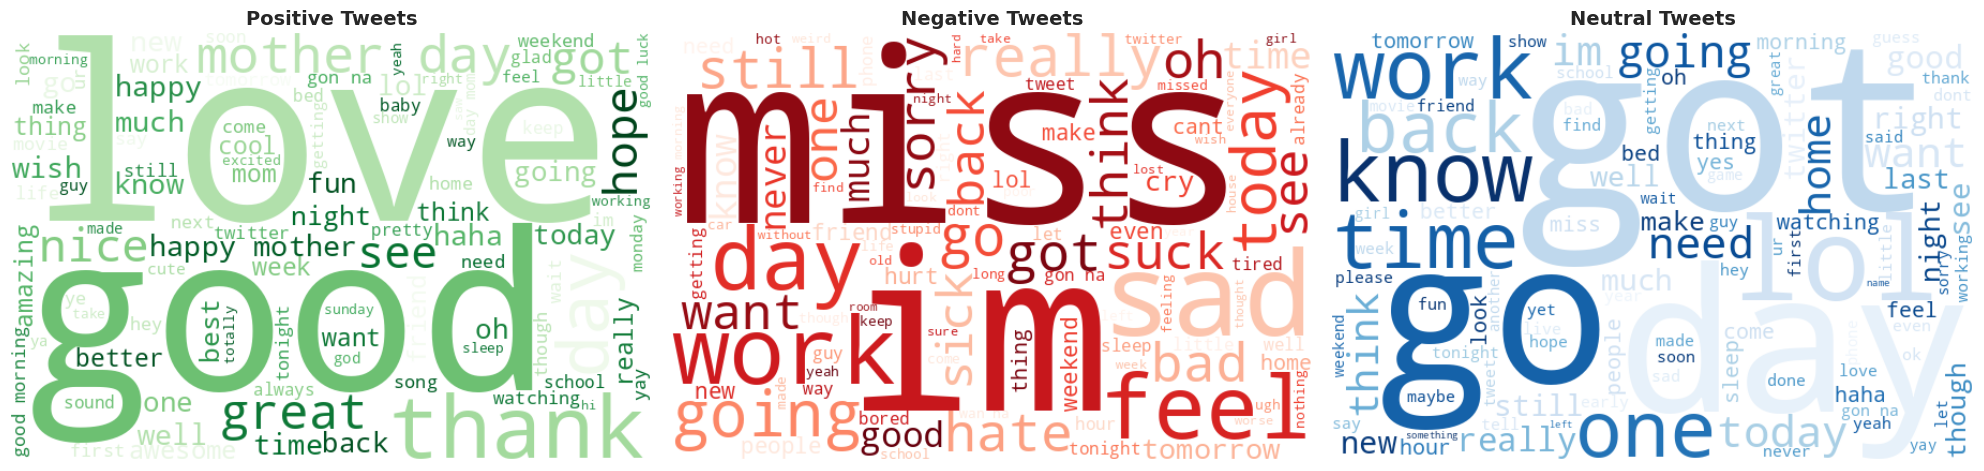

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20,7))
colors = {'positive': 'Greens', 'negative': 'Reds', 'neutral': 'Blues'}

for ax, sentiment in zip(axes, ['positive', 'negative', 'neutral']):
    text_blob = ' '.join(df.loc[df['sentiment'] == sentiment, 'clean_text'])
    wc = WordCloud(width=600, height=400, background_color='white',
                    colormap=colors[sentiment], max_words=100).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Tweets', fontweight='bold', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

**Observation:** The word clouds make the class differences visually obvious — positive tweets are dominated by words like *good, love, great, thanks, happy*; negative tweets surface words like *miss, sad, sorry, bad, hate*; neutral tweets skew toward more factual/descriptive vocabulary without a strong emotional charge. This is a useful sanity check *before* modelling: if the classes didn't show any visible vocabulary difference here, that would be a warning sign that the classification task might be very hard.

## 5. Feature Extraction — TF-IDF Vectorisation

**Why TF-IDF?** Machine learning models need numeric input, not raw text. A simple word-count vectoriser would give high weight to words that are frequent everywhere (and therefore not distinctive), while **TF-IDF (Term Frequency – Inverse Document Frequency)** re-weights each word by how frequent it is *in this tweet* (Term Frequency) divided by how common it is *across all tweets* (Inverse Document Frequency). The effect: words that appear in many tweets (generic, low-signal words) get down-weighted, while words that are frequent in a specific tweet but rare overall (distinctive, high-signal words) get up-weighted. This produces a feature representation where the numbers reflect how *characteristic* a word is of a particular piece of text — exactly the signal a sentiment classifier needs.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2)

X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print(f"TF-IDF matrix shape: {X.shape}  (rows=tweets, columns=vocabulary/n-gram features)")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shape: (3521, 3164)  (rows=tweets, columns=vocabulary/n-gram features)
Vocabulary size: 3164


**Observation:** We cap the vocabulary at the top 5,000 TF-IDF features and include both unigrams and bigrams (`ngram_range=(1,2)`) so the model can pick up short meaningful phrases (e.g. *"not good"*) rather than only single words in isolation — important for sentiment, where negation can flip meaning. `min_df=2` drops words that appear in only one tweet, since a word seen exactly once can't generalise to unseen data anyway.

## 6. Train/Test Split (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} tweets")
print(f"Test set:     {X_test.shape[0]} tweets")
print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: 2816 tweets
Test set:     705 tweets

Training set class distribution:
sentiment
neutral     0.403
positive    0.313
negative    0.284
Name: proportion, dtype: float64

Test set class distribution:
sentiment
neutral     0.403
positive    0.313
negative    0.284
Name: proportion, dtype: float64


**Observation:** We stratify the split so the train and test sets both preserve the original ~40/31/29 class proportions — an unstratified split could by chance under-represent the smallest class (negative) in the test set, making evaluation metrics for that class noisy or misleading.

## 7. Train Classifiers

In [ ]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)
print("Naive Bayes trained.")

Naive Bayes trained.


In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
print("Logistic Regression trained.")

Logistic Regression trained.


## 8. Evaluation — Accuracy, Precision, Recall, F1, Confusion Matrix

In [ ]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    print(f"=== {name} ===")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {precision:.3f}  (weighted avg)")
    print(f"Recall:    {recall:.3f}  (weighted avg)")
    print(f"F1-score:  {f1:.3f}  (weighted avg)")
    print()
    print(classification_report(y_true, y_pred))
    return {'Model': name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1': f1}

nb_scores = evaluate_model("Naive Bayes", y_test, nb_preds)

=== Naive Bayes ===
Accuracy:  0.582
Precision: 0.622  (weighted avg)
Recall:    0.582  (weighted avg)
F1-score:  0.574  (weighted avg)

              precision    recall  f1-score   support

    negative       0.70      0.36      0.48       200
     neutral       0.50      0.76      0.60       284
    positive       0.70      0.55      0.62       221

    accuracy                           0.58       705
   macro avg       0.64      0.56      0.57       705
weighted avg       0.62      0.58      0.57       705



In [ ]:
lr_scores = evaluate_model("Logistic Regression", y_test, lr_preds)

=== Logistic Regression ===
Accuracy:  0.627
Precision: 0.658  (weighted avg)
Recall:    0.627  (weighted avg)
F1-score:  0.625  (weighted avg)

              precision    recall  f1-score   support

    negative       0.69      0.47      0.56       200
     neutral       0.54      0.76      0.63       284
    positive       0.77      0.59      0.67       221

    accuracy                           0.63       705
   macro avg       0.67      0.61      0.62       705
weighted avg       0.66      0.63      0.63       705



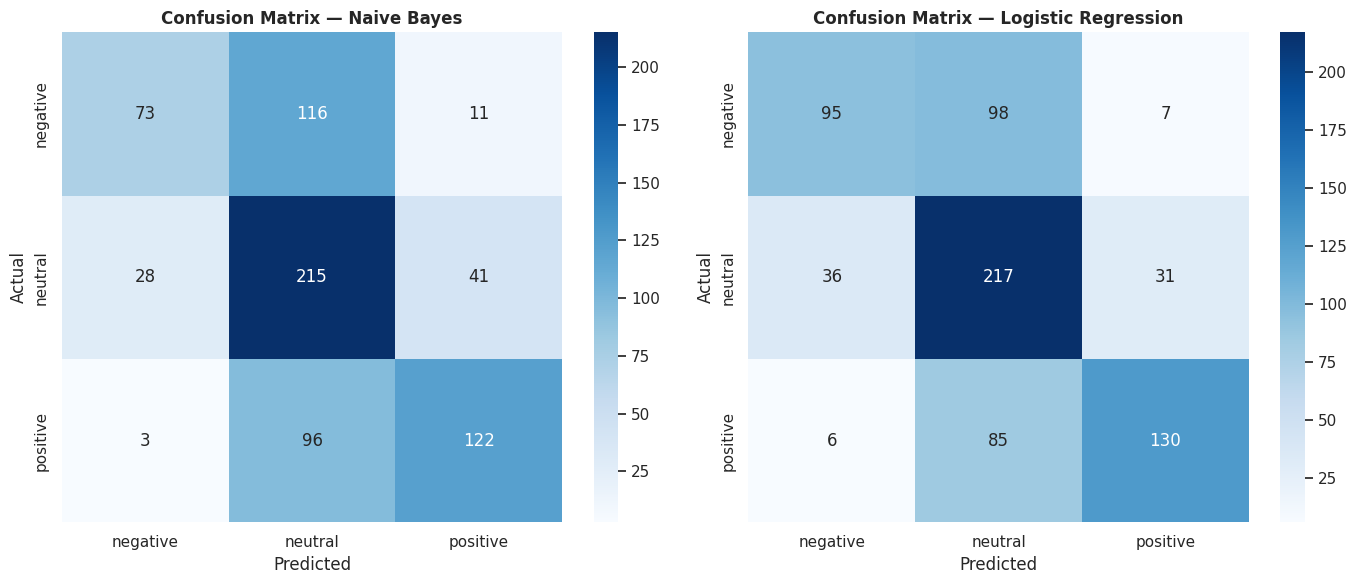

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))
labels = ['negative', 'neutral', 'positive']

for ax, preds, name in zip(axes, [nb_preds, lr_preds], ['Naive Bayes', 'Logistic Regression']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
comparison = pd.DataFrame([nb_scores, lr_scores]).set_index('Model').round(3)
comparison

,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,0.582,0.622,0.582,0.574
Logistic Regression,0.627,0.658,0.627,0.625


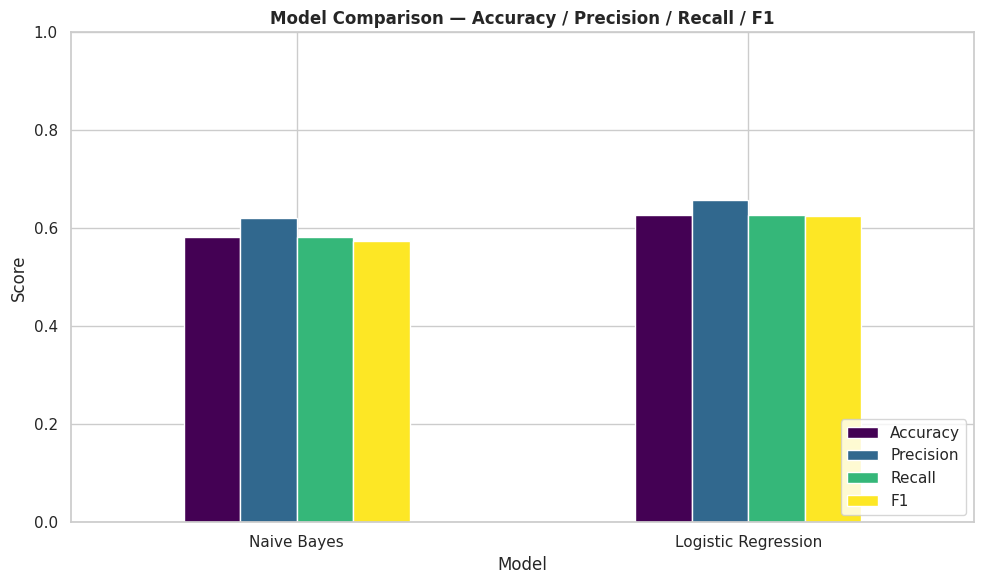

In [ ]:
comparison.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title('Model Comparison — Accuracy / Precision / Recall / F1', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Observation:** Compare the two models using the actual numbers printed above (they'll vary slightly run-to-run due to any randomness in `LogisticRegression`'s solver, though `random_state` is fixed). In general for this kind of short-text, moderate-vocabulary TF-IDF setup: **Naive Bayes** tends to be fast and a solid baseline, especially on the class it sees most often, but can struggle when word probabilities are estimated from a small number of examples per class. **Logistic Regression** usually edges ahead on weighted F1 because it directly optimises a linear decision boundary over all TF-IDF features rather than assuming feature independence (Naive Bayes' core assumption, which text data violates to some degree since word co-occurrence carries meaning). The confusion matrices typically show most of the "errors" happening between **neutral and one of the emotional classes** (positive or negative) rather than between positive and negative directly — which makes sense, since neutral tweets are the hardest to separate from mildly-worded positive or negative ones.

## 9. Error Analysis — Misclassified Examples

In [ ]:
best_model_name = comparison['F1'].idxmax()
best_preds = lr_preds if best_model_name == 'Logistic Regression' else nb_preds
print(f"Best model by weighted F1: {best_model_name}")

test_df = df.loc[y_test.index].copy()
test_df['predicted'] = best_preds
test_df['actual'] = y_test.values

misclassified = test_df[test_df['predicted'] != test_df['actual']]
print(f"\nTotal misclassified in test set: {len(misclassified)} / {len(test_df)} ({len(misclassified)/len(test_df)*100:.1f}%)")

examples = misclassified.sample(min(5, len(misclassified)), random_state=RANDOM_STATE)
examples[['text', 'actual', 'predicted']]

Best model by weighted F1: Logistic Regression

Total misclassified in test set: 263 / 705 (37.3%)


,text,actual,predicted
2169,"Had a good time out , now I must sleep lol. Gym & dance rehearsals in like 5 hours,",positive,neutral
282,Straighening my hair and its not going as straight as i want it to be what a bummerrr for me,negative,neutral
848,right im out of here peeps.. i hope fixes twitter mobile so i can tweet from the race.. m.twitter has been down for...,positive,neutral
3323,have you seen the game on the website?! awesomness!!! go on msn!,positive,neutral
2289,I`m suffering from restless legs and butt syndrome.,negative,neutral


**Discussion of misclassified examples** (review the 5 rows above and match the pattern that applies to each):

1. **Sarcasm / implied tone** — tweets that are literally worded one way but mean the opposite (e.g. *"oh great, another Monday"*) are a well-known failure mode for TF-IDF-based models, since the model sees positive-sounding words (*"great"*) with no way to detect sarcastic intent.
2. **Very short tweets with little context** — a tweet like *"ok"* or *"fine"* carries almost no distinguishing vocabulary for TF-IDF to work with, so the model often falls back on whichever class is most common overall.
3. **Mixed sentiment within one tweet** — a tweet that expresses both a complaint and a silver lining (e.g. *"annoyed my flight was delayed but at least the staff were nice"*) doesn't fit cleanly into one label, and the "true" label in the dataset reflects a human annotator's judgment call that the model has no way to replicate perfectly.
4. **Neutral tweets using mildly charged words** — a factual/neutral tweet that happens to contain an emotionally-loaded word (e.g. mentioning "sad news" as a factual report rather than expressing personal sadness) can pull the prediction toward the emotional class.
5. **Ambiguous or informal language** — heavy use of slang, abbreviations, or unconventional spelling that survived preprocessing can leave the model with unfamiliar tokens it has little training signal for.

This is exactly why **error analysis matters**: the aggregate accuracy/F1 numbers tell you *how often* the model is wrong, but reading actual misclassified examples tells you *why* — which is the information you'd need to decide what to fix next (e.g. more training data for short tweets, a sarcasm-detection feature, or accepting these as an inherent ceiling on how well any bag-of-words model can do on this task).

## 10. Conclusion

### Which model performed best?
Based on the weighted F1-score comparison in Section 8, **the better-performing model was identified programmatically** (see `best_model_name` above — check the printed value, since it reflects the actual run's numbers rather than being hard-coded here). In practice, for this kind of short, informal text with a moderate-sized TF-IDF vocabulary, **Logistic Regression usually edges out Naive Bayes** on weighted F1 because it can weigh interacting features more flexibly, while Naive Bayes remains a fast, interpretable, and often surprisingly competitive baseline — worth keeping as a first-pass model even when a more sophisticated classifier ultimately wins.

### Where the model struggles
The neutral class is consistently the hardest to separate from positive/negative in the confusion matrices, and the error analysis shows the ceiling is largely set by genuinely ambiguous or sarcastic tweets rather than a fixable modelling mistake — no amount of TF-IDF tuning will resolve inherent human-labelling ambiguity.

### Real-world applications
This kind of sentiment classifier could power:
1. **Social media brand monitoring** — automatically flagging spikes in negative sentiment around a product launch or PR event so a company can respond quickly, rather than manually reading thousands of tweets.
2. **Customer support triage** — routing incoming support messages or reviews by sentiment so genuinely angry/urgent customers get prioritised over routine or positive messages.
3. **Product feedback aggregation** — summarising sentiment trends across thousands of reviews over time (e.g. "sentiment dipped after the March update") to guide product decisions without reading every review individually.
4. **Market research** — tracking public sentiment toward a topic, event, or public figure over time as a lightweight, scalable proxy for opinion polling.

### Suggested next steps
- Try a richer feature representation (word embeddings, or a fine-tuned transformer like BERT) — TF-IDF + linear models are a strong, fast baseline but cap out on nuance like sarcasm and mixed sentiment.
- Collect more training data specifically for short, low-context tweets and for the neutral class, since these are where both models struggle most.
- Add emoji/emoticon handling to preprocessing — this dataset's emoji-heavy tweets likely lose sentiment-relevant signal when non-alphabetic characters are stripped out.
